In [5]:
# Task 3: Reinforcement Learning - Simple Grid World
# Objective: Agent learns to navigate to a goal using Q-learning
# No external libraries required - pure Python implementation

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import random

print(" Grid World Navigation - Reinforcement Learning Task \n")

 Grid World Navigation - Reinforcement Learning Task 



In [86]:
# Step 1: Create gridworld environment 
class GridWorld:
    def __init__(self, size=5, start_pos=(0, 0), goal_pos=(4, 4), grid=None):
        self.size = size
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.grid = grid if grid is not None else np.zeros((size, size))
        self.agent_pos = start_pos

    def reset(self):
        """Reset environment to start state"""
        self.agent_pos = self.start_pos
        return self.agent_pos

    def greedy_action(agent, state):
        """Choose the best action (greedy policy) without exploration"""
        if state in agent.q_table:
            return np.argmax(agent.q_table[state])
        else:
        # If state not in Q-table, choose random action
            return np.random.choice([0, 1, 2, 3])
    
    def step(self, action):
        """Take an action and return (next_state, reward, done)"""
        i, j = self.agent_pos

        # Actions: 0=up, 1=down, 2=left, 3=right
        if action == 0 and i > 0:
            i -= 1
        elif action == 1 and i < self.size - 1:
            i += 1
        elif action == 2 and j > 0:
            j -= 1
        elif action == 3 and j < self.size - 1:
            j += 1

        self.agent_pos = (i, j)

        # Rewards
        if self.agent_pos == self.goal_pos:
            return self.agent_pos, 1.0, True
        elif self.grid[i, j] == -1:  # obstacle
            return self.agent_pos, -1.0, True
        else:
            return self.agent_pos, -0.01, False  # small penalty

    def render(self):
        """Visualize the grid"""
        plt.figure(figsize=(5, 5))
        for i in range(self.size):
            for j in range(self.size):
                if (i, j) == self.start_pos:
                    plt.text(j, i, 'S', ha='center', va='center', fontsize=20, color='blue')
                elif (i, j) == self.goal_pos:
                    plt.text(j, i, 'G', ha='center', va='center', fontsize=20, color='green')
                elif (i, j) == self.agent_pos:
                    plt.text(j, i, 'A', ha='center', va='center', fontsize=20, color='red')
                elif self.grid[i, j] == -1:
                    plt.text(j, i, 'X', ha='center', va='center', fontsize=20, color='black')

        plt.title('Grid World Environment\nS=Start, G=Goal, A=Agent, X=Obstacle')
        plt.xticks(range(self.size))
        plt.yticks(range(self.size))
        plt.grid(True, alpha=0.3)
        plt.show()



In [99]:
#Q-Learning Agent
class QLearningAgent:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.q_table = {}  # state -> action values

    def get_state_key(self, state):
        return tuple(state)
    
    def get_action(self, state, training=True):
        """Choose action using epsilon-greedy policy.
           If training=False → always choose greedy (best action)."""
        if training and np.random.rand() < self.eplison:
            return np.random.randit(self.action_size)
        return np.argmax(self.q_table[state])


    def choose_action(self, state):
        state_key = self.get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(4)  # 4 actions

        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, 3)  # explore
        else:
            return np.argmax(self.q_table[state_key])  # exploit

    def learn(self, state, action, reward, next_state):
        state_key = self.get_state_key(state)
        next_key = self.get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(4)
        if next_key not in self.q_table:
            self.q_table[next_key] = np.zeros(4)

        best_next = np.max(self.q_table[next_key])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state_key][action]

        self.q_table[state_key][action] += self.alpha * td_error

In [100]:
#Training loop
def train_agent(agent, env, num_episodes=1000, max_steps=100):
    rewards = []
    lengths = []
    successes = []

    for ep in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)

            state = next_state
            total_reward += reward

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)

        if state == env.goal_pos:
            successes.append(1)
        else:
            successes.append(0)

        # Decay exploration
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

    return rewards, lengths, successes

Starting training...
Training finished! Success rate = 489/500


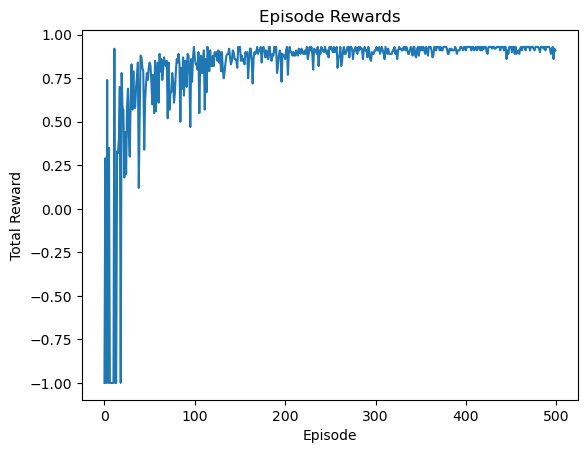

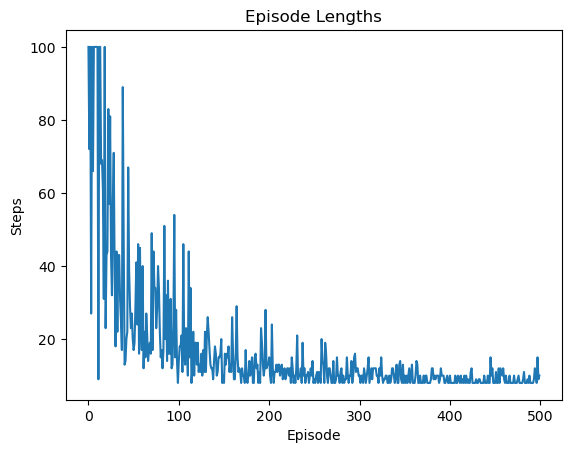

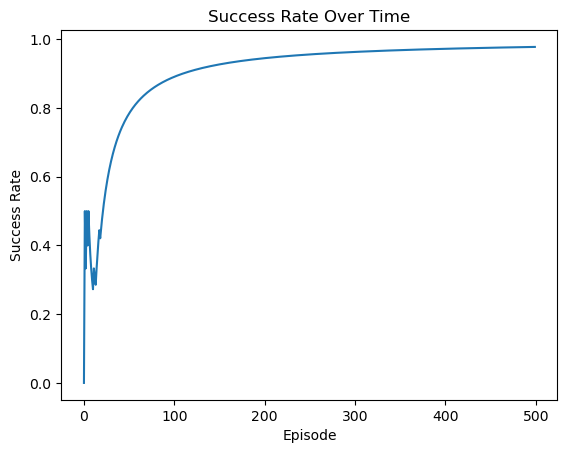

In [101]:
#run trainings and plot results
print("Starting training...")
env = GridWorld(size=5, start_pos=(0, 0), goal_pos=(4, 4))
agent = QLearningAgent()

rewards, lengths, successes = train_agent(agent, env, num_episodes=500)

print(f"Training finished! Success rate = {sum(successes)}/{len(successes)}")

# Plot Rewards
plt.plot(rewards)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# Plot Episode Lengths
plt.plot(lengths)
plt.title("Episode Lengths")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Plot Success Rate
plt.plot(np.cumsum(successes) / (np.arange(len(successes)) + 1))
plt.title("Success Rate Over Time")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.show()

Text(0.5, 1.0, 'Q-values for "Right" Action')

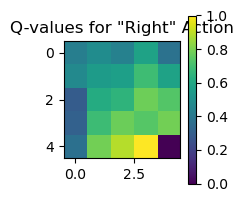

In [102]:
# Plot 4: Q-table heatmap (values for "right" action)
plt.subplot(2, 3, 4)
q_values_right = np.zeros((env.size, env.size))
for i in range(env.size):
    for j in range(env.size):
        q_values_right[i, j] = agent.q_table[(i, j)][3]  # Right action
plt.imshow(q_values_right, cmap='viridis')
plt.colorbar()
plt.title('Q-values for "Right" Action')


Step 7: Testing trained agent...
Testing agent for 5 episodes...
Test 1: SUCCESS in 8 steps, Reward: 0.93
Agent's path:
Step 0: (0, 0)
Step 1: (0, 1)
Step 2: (0, 2)
Step 3: (1, 2)
Step 4: (2, 2)
Step 5: (3, 2)
Step 6: (4, 2)
Step 7: (4, 3)
Step 8: (4, 4)


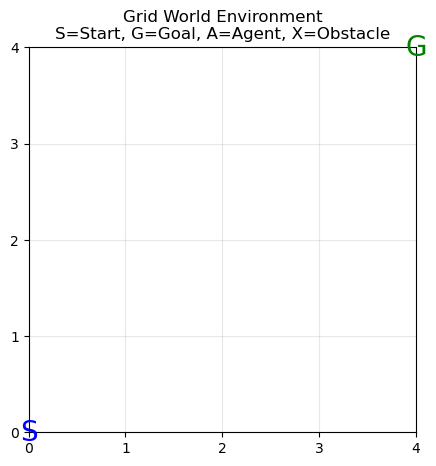

Test 2: SUCCESS in 8 steps, Reward: 0.93
Test 3: SUCCESS in 8 steps, Reward: 0.93
Test 4: SUCCESS in 8 steps, Reward: 0.93
Test 5: SUCCESS in 8 steps, Reward: 0.93


In [103]:
print("\nStep 7: Testing trained agent...")

def test_agent(agent, env, num_tests=5, render_path=True):
    """Test the trained agent"""
    print(f"Testing agent for {num_tests} episodes...")
    
    test_results = []
    
    for test in range(num_tests):
        state = env.reset()
        path = [state]
        total_reward = 0
        steps = 0
        
        for step in range(50):  # Max 50 steps
            # Use greedy policy (no epsilon exploration)
            state_key = agent.get_state_key(state)
            if state_key in agent.q_table:
                action = np.argmax(agent.q_table[state_key])
            else:
                action = np.random.randint(0, 4)  # fallback random action
            
            next_state, reward, done = env.step(action)
            
            path.append(next_state)
            state = next_state
            total_reward += reward
            steps += 1
            
            if done:
                break
        
        success = (state == env.goal_pos)
        test_results.append((success, steps, total_reward, path))
        
        print(f"Test {test+1}: {'SUCCESS' if success else 'FAILED'} in {steps} steps, Reward: {total_reward:.2f}")
        
        if render_path and test == 0:  # Show path for first test
            print("Agent's path:")
            for i, pos in enumerate(path):
                print(f"Step {i}: {pos}")
            env.render()
    
    return test_results


# Run tests
test_results = test_agent(agent, env)

In [104]:
psilon_decay)

SyntaxError: unmatched ')' (2734322779.py, line 1)


Step 8: Visualizing learned policy...


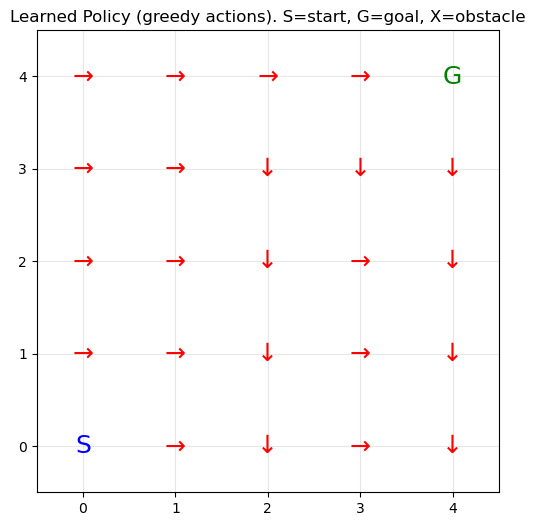

In [105]:
print("\nStep 8: Visualizing learned policy...")

def visualize_policy(agent, env):
    plt.figure(figsize=(6, 6))
    arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    # draw background (obstacles as -1, empty 0)
    plt.imshow(np.zeros((env.size, env.size)), cmap='Greys', alpha=0.0)  # blank background

    for i in range(env.size):
        for j in range(env.size):
            pos = (i, j)
            if pos == env.start_pos:
                plt.text(j, i, 'S', ha='center', va='center', fontsize=18, color='blue')
            elif pos == env.goal_pos:
                plt.text(j, i, 'G', ha='center', va='center', fontsize=18, color='green')
            elif env.grid[i, j] == -1:
                plt.text(j, i, 'X', ha='center', va='center', fontsize=18, color='black')
            else:
                # choose greedy action if available
                key = agent.get_state_key(pos)
                if key in agent.q_table:
                    best_action = int(np.argmax(agent.q_table[key]))
                    plt.text(j, i, arrows[best_action], ha='center', va='center', fontsize=18, color='red')
                else:
                    plt.text(j, i, '·', ha='center', va='center', fontsize=18, color='gray')  # unknown

    plt.title('Learned Policy (greedy actions). S=start, G=goal, X=obstacle')
    plt.xticks(range(env.size))
    plt.yticks(range(env.size))
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()   # so (0,0) visually sits at top-left like your render
    plt.show()

visualize_policy(agent, env)
    


Step 9: Demonstrating optimal path (greedy policy)...
Starting at: (0, 0)
Step 1: Action Right -> (0, 1), Reward: -0.01
Step 2: Action Right -> (0, 2), Reward: -0.01
Step 3: Action Down -> (1, 2), Reward: -0.01
Step 4: Action Down -> (2, 2), Reward: -0.01
Step 5: Action Down -> (3, 2), Reward: -0.01
Step 6: Action Down -> (4, 2), Reward: -0.01
Step 7: Action Right -> (4, 3), Reward: -0.01
Step 8: Action Right -> (4, 4), Reward: 1.00
✅ Goal reached in 8 steps!

Final Environment State:


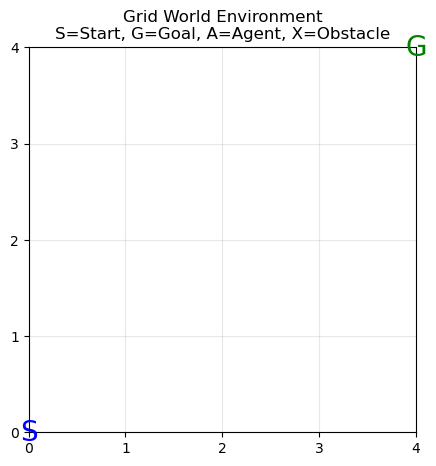

In [106]:
print("\nStep 9: Demonstrating optimal path (greedy policy)...")

state = env.reset()
optimal_path = [state]
print(f"Starting at: {state}")

for step in range(20):  # Max 20 steps
    # Use trained policy without exploration
    action = agent.get_action(state, training=False)
    next_state, reward, done = env.step(action)
    optimal_path.append(next_state)

    action_name = ['Up', 'Down', 'Left', 'Right'][action]
    print(f"Step {step+1}: Action {action_name} -> {next_state}, Reward: {reward:.2f}")

    state = next_state
    if done:
        if state == env.goal_pos:
            print(f"✅ Goal reached in {step+1} steps!")
        else:
            print(f"❌ Episode ended by obstacle in {step+1} steps.")
        break

# Show final render
print("\nFinal Environment State:")
env.render()


In [108]:
# Step 10: Summary and Analysis
print("\nStep 10: Final Analysis...")

# Calculate test statistics
successful_tests = sum(1 for result in test_results if result[0])
avg_steps = np.mean([result[1] for result in test_results if result[0]]) if successful_tests > 0 else None

print("\n" + "="*60)
print("TASK 3 COMPLETED: REINFORCEMENT LEARNING")
print("="*60)
print(f"✓ Environment: {env.size}x{env.size} Grid World")
print(f"✓ Algorithm: Q-Learning with epsilon-greedy exploration")

if 'episode_rewards' in globals():
    print(f"✓ Training Episodes: {len(episode_rewards)}")
    print(f"✓ Training Success Rate: {len(success_episodes)}/{len(episode_rewards)} "
          f"({len(success_episodes)/len(episode_rewards)*100:.1f}%)")
else:
    print("⚠ Training statistics not available (episode_rewards missing).")

print(f"✓ Test Success Rate: {successful_tests}/{len(test_results)} "
      f"({successful_tests/len(test_results)*100:.1f}%)")

if avg_steps is not None:
    print(f"✓ Average Steps to Goal (successful runs): {avg_steps:.1f}")

print(f"✓ Q-table Size: {len(agent.q_table)} states learned")
print("✓ Agent learned optimal navigation policy through trial and error")
print("✓ Demonstrated exploration vs exploitation trade-off")
print("="*60)



Step 10: Final Analysis...

TASK 3 COMPLETED: REINFORCEMENT LEARNING
✓ Environment: 5x5 Grid World
✓ Algorithm: Q-Learning with epsilon-greedy exploration
⚠ Training statistics not available (episode_rewards missing).
✓ Test Success Rate: 5/5 (100.0%)
✓ Average Steps to Goal (successful runs): 8.0
✓ Q-table Size: 25 states learned
✓ Agent learned optimal navigation policy through trial and error
✓ Demonstrated exploration vs exploitation trade-off
